# Tensorflow

In [1]:
pip install tensorflow torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
import os
import zipfile
import urllib.request
from PIL import Image

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()


In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [5]:
# Bana rha hu CNN betwa

basic_cnn = tf.keras.Sequential([
    # 32 diff filter of size 3*3 input is [28,28,1] 1-> for grayscale
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(10, activation='softmax')  # 10 classes
])


# Model ra babu
basic_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Summary likho re")
basic_cnn.summary()

print("\nTraining Basic CNN Model (5 epochs for demonstration)...")
history = basic_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5
)

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


Summary likho re


d:\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,266 (501.04 KB)

 Trainable params: 128,266 (501.04 KB)

 Non-trainable params: 0 (0.00 B)


Training Basic CNN Model (5 epochs for demonstration)...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9372 - loss: 0.1981 - val_accuracy: 0.9752 - val_loss: 0.0794
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9798 - loss: 0.0673 - val_accuracy: 0.9857 - val_loss: 0.0491
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9850 - loss: 0.0482 - val_accuracy: 0.9840 - val_loss: 0.0547
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9885 - loss: 0.0382 - val_accuracy: 0.9846 - val_loss: 0.0519
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9905 - loss: 0.0301 - val_accuracy: 0.9867 - val_loss: 0.0455
Final Training Accuracy: 0.9905
Final Validation Accuracy: 0.9867


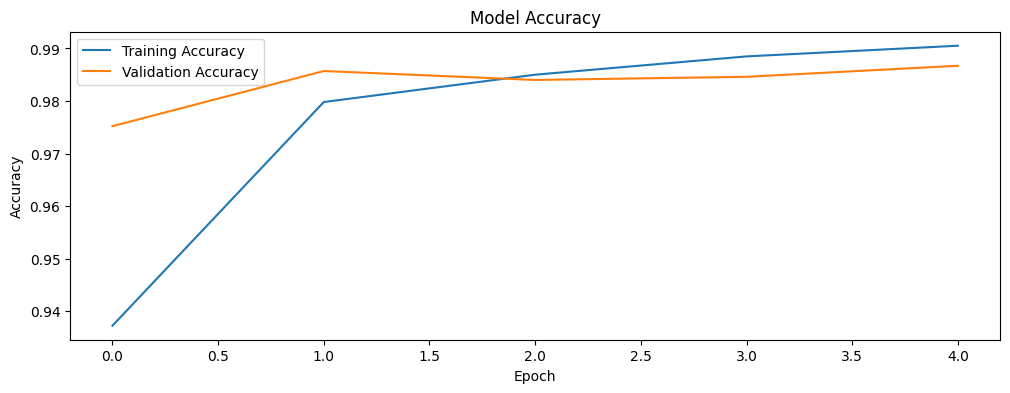

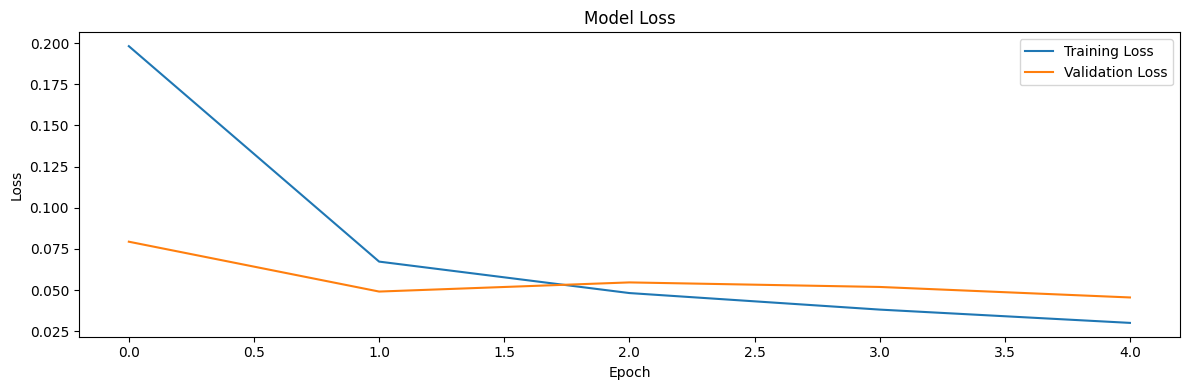

: 

In [ ]:
# History plot kr rha hu mai
plt.figure(figsize=(12,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.figure(figsize=(12,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


# Pretrained Model

In [ ]:
import tensorflow as tf

# Add a channel dimension of 1 for grayscale images (e.g., (60000, 28, 28) -> (60000, 28, 28, 1))
X_train_expanded = tf.expand_dims(X_train, axis=-1)
X_test_expanded = tf.expand_dims(X_test, axis=-1)

# Resize to 96x96 (e.g., (60000, 28, 28, 1) -> (60000, 96, 96, 1))
X_train_resized_1_channel = tf.image.resize(X_train_expanded, (96, 96))
X_test_resized_1_channel = tf.image.resize(X_test_expanded, (96, 96))

# Convert 1 channel -> 3 channels (e.g., (60000, 96, 96, 1) -> (60000, 96, 96, 3))
X_train_resized = tf.image.grayscale_to_rgb(X_train_resized_1_channel)
X_test_resized = tf.image.grayscale_to_rgb(X_test_resized_1_channel)


print("New shape:", X_train_resized.shape)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,   # remove original classifier
    weights='imagenet'
)

base_model.trainable = False   # Freeze base model

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')   # 10 classes
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_resized, y_train,
    validation_data=(X_test_resized, y_test),
    epochs=5
)

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# Pytorch Implementation

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets

In [ ]:
# (mean_R, mean_G, mean_B)
# (std_R, std_G, std_B)
# 0.5 single means for the grayscale image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading re
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
# print("Test dataset shape", test_dataset.shape)


Train size: 60000


In [ ]:
class CNN(nn.Module):
  def __init__(self, kernel_size, num_filters, num_classes):
    super(CNN, self).__init__()

    # Takes a grayscale image and applies 32 different 3×3 filters to it.
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=kernel_size)
    self.pool = nn.MaxPool2d(kernel_size = (2, 2))
    self.conv2 = nn.Conv2d(32, 64, 3)
    self.conv3 = nn.Conv2d(64, 128, 3)

    self.fc1 = nn.Linear(128*1*1 , 256)
    self.fc2 = nn.Linear(256, 10)      # 10 classes

    self.relu = nn.ReLU()

  def forward(self, x):
    # x [1, 28, 28]
    x = self.pool(self.conv1(x)) #[32, 13, 13]
    x = self.pool(self.conv2(x)) #[64, 5, 5]
    x = self.pool(self.conv3(x)) #[128, 1, 1]

    x = x.view(x.size(0), -1)   # flatten

    x = self.relu(self.fc1(x))
    x = self.fc2(x)

    return x

In [16]:
model = CNN(kernel_size=3, num_filters=32, num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")



Epoch [1/5], Loss: 175.0846
Epoch [2/5], Loss: 61.5010


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        # max_score, class  

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")





In [ ]:
import matplotlib.pyplot as plt
import torch

# Set model to evaluation mode
model.eval()

# Get one batch from test loader
images, labels = next(iter(test_loader))


# Get predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Plot first 10 images
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Actual: {labels[i].item()}\nPred: {predicted[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()